## Sentiment Classification on IMDB Dataset
### Using Additive and Multiplicative Attention with LSTMs

**Dataset:** IMDB Movie Reviews


**Imports**

In [3]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
os.getcwd()

'/content'

In [6]:
os.chdir('/content/drive/MyDrive/Classroom/BBD 7/Adv Deep Learning')

In [7]:
os.getcwd()

'/content/drive/MyDrive/Classroom/BBD 7/Adv Deep Learning'

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

In [10]:
# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [11]:
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

**Load IMDB Dataset**

In [13]:
df = pd.read_csv('/content/IMDB Dataset.csv')

In [14]:
print(df.shape)
print(df['sentiment'].value_counts())
df.head(3)

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [15]:
# Map labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df['label'].value_counts())

label
1    25000
0    25000
Name: count, dtype: int64


**Feature Engineering & Preprocessing**

**Strategy:**
1. **Standard cleaning** — lowercase, remove HTML tags, URLs, special chars
2. **Negation tagging** — tag words after 'not/no/never' with `_NEG` suffix to capture negation context (e.g., 'not good' → 'good_NEG')
3. **Elongated word normalization** — 'gooood' → 'good'
4. **Contraction expansion** — "isn't" → "is not"
5. **Vocabulary built from top-N most frequent words**

In [16]:
# ─── Contraction map ────────────────────────────────────────────────────────
CONTRACTIONS = {
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "won't": "will not", "wouldn't": "would not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "shouldn't": "should not",
    "mightn't": "might not", "mustn't": "must not", "shan't": "shall not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "they're": "they are",
    "that's": "that is", "there's": "there is", "what's": "what is",
}

In [17]:
NEGATION_WORDS = {'not', 'no', 'never', 'none', 'nobody', 'nothing',
                  'neither', 'nor', 'nowhere', 'hardly', 'scarcely',
                  'barely', 'doesnt', 'isnt', 'wasnt', 'wouldnt',
                  'couldnt', 'shouldnt', 'wont', 'cant', 'cannot'}


In [18]:
def expand_contractions(text):
    """Expand English contractions."""
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text


In [19]:
def normalize_elongated(text):
    """Reduce repeated chars: 'gooood' → 'good'."""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)  # keep at most 2

In [20]:
def tag_negation(tokens):
    """
    Tag tokens that follow a negation word with '_NEG'.
    Negation scope ends at punctuation or after 3 words.
    """
    result = []
    negate = False
    neg_count = 0
    for token in tokens:
        if token in NEGATION_WORDS:
            negate = True
            neg_count = 0
            result.append(token)
        elif negate:
            if neg_count < 3:
                result.append(token + '_NEG')
                neg_count += 1
            else:
                negate = False
                result.append(token)
        else:
            result.append(token)
    return result

In [21]:
def clean_text(text, use_negation=True):
    """Full preprocessing pipeline."""
    text = text.lower()
    text = expand_contractions(text)
    text = re.sub(r'<[^>]+>', ' ', text)       # remove HTML tags
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = normalize_elongated(text)
    text = re.sub(r'[^a-z\s_]', '', text)     # keep letters, spaces, _ (for _NEG)
    tokens = text.split()
    if use_negation:
        tokens = tag_negation(tokens)
    return ' '.join(tokens)

In [22]:
# Quick test
test_sentences = [
    "This movie isn't good at all!",
    "@user http://link.com I absolutely LOOOOVED it!!!",
    "Not a bad film, but nothing special either.",
]
for s in test_sentences:
    print(f'Original : {s}')
    print(f'Cleaned  : {clean_text(s)}')
    print()

Original : This movie isn't good at all!
Cleaned  : this movie is not good_NEG at_NEG all_NEG

Original : @user http://link.com I absolutely LOOOOVED it!!!
Cleaned  : i absolutely looved it

Original : Not a bad film, but nothing special either.
Cleaned  : not a_NEG bad_NEG film_NEG but nothing special_NEG either_NEG



In [23]:
# Apply cleaning to the full dataframe
print('Cleaning reviews... (this may take ~1 min)')
df['clean_review'] = df['review'].apply(clean_text)
print('Done!')
df[['review','clean_review','label']].head(3)

Cleaning reviews... (this may take ~1 min)
Done!


,review,clean_review,label
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,1


**Tokenisation & Vocabulary**




In [24]:
def tokenize(text):
    return text.split()

In [25]:
# Build vocabulary from all words
all_words = []
for review in df['clean_review']:
    all_words.extend(tokenize(review))

In [26]:
print(f'Total tokens: {len(all_words):,}')
print(f'Unique tokens: {len(set(all_words)):,}')

Total tokens: 11,489,938
Unique tokens: 181,838


In [27]:
VOCAB_SIZE = 20000
word_counts = Counter(all_words)
vocab = {word: idx + 1  # 0 reserved for padding
         for idx, (word, _) in enumerate(word_counts.most_common(VOCAB_SIZE))}

In [28]:
print(f'Vocabulary size (top-{VOCAB_SIZE}): {len(vocab):,}')
print('Sample vocab entries:', list(vocab.items())[:10])

Vocabulary size (top-20000): 20,000
Sample vocab entries: [('the', 1), ('and', 2), ('a', 3), ('of', 4), ('is', 5), ('to', 6), ('in', 7), ('it', 8), ('i', 9), ('this', 10)]


In [29]:
MAX_LEN = 300  # IMDB reviews are much longer than tweets

In [30]:
def encode(text):
    """Convert text to padded/truncated integer sequence."""
    tokens = tokenize(text)
    encoded = [vocab.get(w, 0) for w in tokens]
    # Pad or truncate to MAX_LEN
    if len(encoded) < MAX_LEN:
        encoded += [0] * (MAX_LEN - len(encoded))
    return encoded[:MAX_LEN]

In [31]:
# Encode all reviews
X = np.array([encode(r) for r in df['clean_review']])
Y = np.array(df['label'])
print(f'X shape: {X.shape}  |  Y shape: {Y.shape}')

X shape: (50000, 300)  |  Y shape: (50000,)


In [32]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (40000, 300)  |  Test: (10000, 300)


In [33]:
# Convert to tensors
X_train_t = torch.LongTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.LongTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

**Model Architectures**

1 Additive Attention (Bahdanau)
$$score(h_t, \bar{h}_s) = v_a^T \tanh(W_1 h_t + W_2 \bar{h}_s)$$

2 Multiplicative Attention (Luong / Dot-product)
$$score(h_t, \bar{h}_s) = h_t^T W \bar{h}_s$$

In [34]:
# Additive (Bahdanau) Attention
class AdditiveAttention(nn.Module):
    """
    Bahdanau-style attention:
      score = V * tanh(W1 * encoder_out + W2 * query)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.V  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, encoder_outputs, hidden):
        # hidden: (num_layers * num_directions, batch, hidden_dim)
        query = hidden[-1].unsqueeze(1)               # (batch, 1, hidden_dim)
        score = self.V(
            torch.tanh(self.W1(encoder_outputs) + self.W2(query))
        )                                             # (batch, seq_len, 1)
        weights = torch.softmax(score, dim=1)         # (batch, seq_len, 1)
        context = torch.sum(weights * encoder_outputs, dim=1)  # (batch, hidden_dim)
        return context, weights

In [35]:
# Multiplicative (Luong) Attention  ← FIXED with scaled dot-product
import math

class MultiplicativeAttention(nn.Module):
    """
    Luong 'general' attention with scaled dot-product:
      score = (query^T * W * encoder_out) / sqrt(d_k)
    Scaling by sqrt(d_k) prevents softmax saturation.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.scale = math.sqrt(hidden_dim)   # ← store scale factor

    def forward(self, encoder_outputs, hidden):
        query  = hidden[-1].unsqueeze(2)               # (batch, hidden_dim, 1)
        energy = self.W(encoder_outputs)               # (batch, seq_len, hidden_dim)
        score  = torch.bmm(energy, query) / self.scale # (batch, seq_len, 1)  ← FIXED
        weights = torch.softmax(score, dim=1)          # now properly distributed
        context = torch.sum(weights * encoder_outputs, dim=1)
        return context, weights

In [36]:
# Multiplicative (Luong) Attention
#class MultiplicativeAttention(nn.Module):
 #   """
  #  Luong 'general' attention:
   #   score = query^T * W * encoder_out
    #"""
    #def __init__(self, hidden_dim):
     #   super().__init__()
      #  self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)

    #def forward(self, encoder_outputs, hidden):
     #   query = hidden[-1].unsqueeze(2)               # (batch, hidden_dim, 1)
      #  # W * encoder_outputs:  (batch, seq_len, hidden_dim)
       # energy = self.W(encoder_outputs)              # (batch, seq_len, hidden_dim)
        #score = torch.bmm(energy, query)              # (batch, seq_len, 1)
        #weights = torch.softmax(score, dim=1)         # (batch, seq_len, 1)
        #context = torch.sum(weights * encoder_outputs, dim=1)  # (batch, hidden_dim)
        #return context, weights

  #The original multiplicative attention omitted the scaling factor √d_k from the original Attention Is All You Need paper.
  #With hidden_dim=512, raw dot-product scores grew too large, causing softmax to produce near-one-hot distributions that collapsed to zero
  # for most tokens during backprop. Adding division by √512 keeps scores in a numerically stable range, allowing the softmax to produce
  # meaningful distributed weights.

In [37]:
# Unified Sentiment Classifier
class SentimentLSTM(nn.Module):
    """
    Bidirectional LSTM + attention for sentiment classification.
    attention_type: 'additive' | 'multiplicative'
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=2, dropout=0.3, attention_type='additive'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        # Bidirectional → hidden_dim * 2 for all attention layers
        attn_dim = hidden_dim * 2
        if attention_type == 'additive':
            self.attention = AdditiveAttention(attn_dim)
        elif attention_type == 'multiplicative':
            self.attention = MultiplicativeAttention(attn_dim)
        else:
            raise ValueError(f'Unknown attention type: {attention_type}')

        self.dropout  = nn.Dropout(dropout)
        self.fc       = nn.Linear(attn_dim, 64)
        self.out      = nn.Linear(64, 1)
        self.sigmoid  = nn.Sigmoid()
        self.attention_type = attention_type

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))    # (batch, seq, embed)
        outputs, (hidden, cell) = self.lstm(embedded) # outputs: (batch,seq,hidden*2)
        # Concatenate forward & backward last hidden states for attention query
        # hidden: (num_layers*2, batch, hidden_dim) — take last layer's both directions
        hidden_cat = torch.cat([hidden[-2], hidden[-1]], dim=1).unsqueeze(0)
        # hidden_cat: (1, batch, hidden*2)  → attention expects (layers, batch, dim)
        context, attn_weights = self.attention(outputs, hidden_cat)
        context = self.dropout(context)
        fc_out  = torch.relu(self.fc(context))
        logit   = self.out(self.dropout(fc_out))
        return self.sigmoid(logit), attn_weights


print('Model classes defined.')

Model classes defined.


**Training & Evaluation Utilities**

In [38]:
def train_model(model, optimizer, criterion, X_train, y_train,
                batch_size=64, epochs=10):
    """Mini-batch training loop. Returns per-epoch losses."""
    model.train()
    losses = []
    n = len(X_train)
    for epoch in range(epochs):
        # Shuffle each epoch
        perm = torch.randperm(n)
        X_train = X_train[perm]
        y_train = y_train[perm]

        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            xb = X_train[i:i+batch_size]
            yb = y_train[i:i+batch_size].unsqueeze(1)
            optimizer.zero_grad()
            preds, _ = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss)
        print(f'  Epoch {epoch+1:02d}/{epochs}  Loss: {epoch_loss:.4f}')
    return losses

In [39]:
def evaluate_model(model, X_test, y_test, batch_size=64):
    """Print confusion matrix, classification report & return accuracy."""
    model.eval()
    all_preds = []
    all_labels = []
    n = len(X_test)
    with torch.no_grad():
        for i in range(0, n, batch_size):
            xb = X_test[i:i+batch_size]
            yb = y_test[i:i+batch_size]
            preds, _ = model(xb)
            all_preds.append((preds > 0.5).float().squeeze().cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    preds_bin = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    print('Confusion Matrix:')
    print(confusion_matrix(y_true, preds_bin))
    print('Classification Report:')
    print(classification_report(y_true, preds_bin,
                                target_names=['Negative','Positive']))
    acc = accuracy_score(y_true, preds_bin)
    f1  = f1_score(y_true, preds_bin)
    return acc, f1

In [40]:
def plot_loss(losses, title):
    plt.figure(figsize=(7, 4))
    plt.plot(losses, marker='o', markersize=4)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print('Utilities defined.')

Utilities defined.


**Experiment 1: Additive Attention + BCE Loss + Adam**

In [41]:
EMBED_DIM  = 128
HIDDEN_DIM = 256
EPOCHS     = 10
BATCH_SIZE = 64
LR         = 1e-3

In [42]:
print('Experiment 1: Additive Attention + BCELoss + Adam')
model_add_bce = SentimentLSTM(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    attention_type='additive'
).to(device)

Experiment 1: Additive Attention + BCELoss + Adam


In [43]:
optimizer_add = optim.Adam(model_add_bce.parameters(), lr=LR)
criterion_bce = nn.BCELoss()

In [44]:
losses_add_bce = train_model(
    model_add_bce, optimizer_add, criterion_bce,
    X_train_t, y_train_t, BATCH_SIZE, EPOCHS
)

  Epoch 01/10  Loss: 285.0509
  Epoch 02/10  Loss: 180.2796
  Epoch 03/10  Loss: 144.1672
  Epoch 04/10  Loss: 121.2596
  Epoch 05/10  Loss: 102.7290
  Epoch 06/10  Loss: 84.3738
  Epoch 07/10  Loss: 68.1887
  Epoch 08/10  Loss: 54.7571
  Epoch 09/10  Loss: 45.5449
  Epoch 10/10  Loss: 36.6749


Confusion Matrix:
[[4292  708]
 [ 292 4708]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.86      0.90      5000
    Positive       0.87      0.94      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



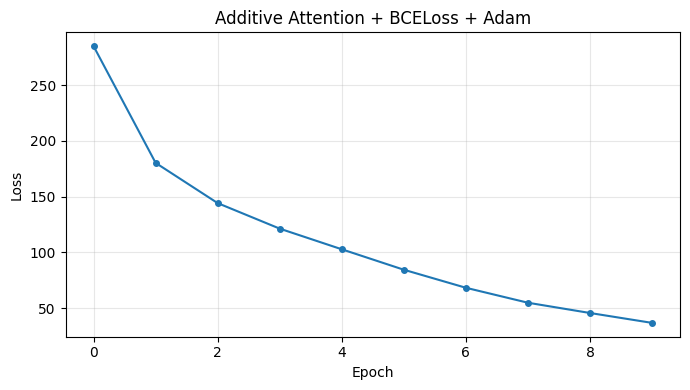

In [45]:
acc1, f1_1 = evaluate_model(model_add_bce, X_test_t, y_test_t, BATCH_SIZE)
plot_loss(losses_add_bce, 'Additive Attention + BCELoss + Adam')

**Experiment 2: Multiplicative Attention + BCE Loss + Adam**

In [46]:
print('Experiment 2: Multiplicative Attention + BCELoss + Adam')
model_mul_bce = SentimentLSTM(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    attention_type='multiplicative'
).to(device)

Experiment 2: Multiplicative Attention + BCELoss + Adam


In [47]:
optimizer_mul = optim.Adam(model_mul_bce.parameters(), lr=LR)

losses_mul_bce = train_model(
    model_mul_bce, optimizer_mul, criterion_bce,
    X_train_t, y_train_t, BATCH_SIZE, EPOCHS
)


  Epoch 01/10  Loss: 291.7209
  Epoch 02/10  Loss: 181.5665
  Epoch 03/10  Loss: 144.7218
  Epoch 04/10  Loss: 121.8330
  Epoch 05/10  Loss: 97.8612
  Epoch 06/10  Loss: 82.1411
  Epoch 07/10  Loss: 67.3104
  Epoch 08/10  Loss: 54.0059
  Epoch 09/10  Loss: 43.5346
  Epoch 10/10  Loss: 38.9166


Confusion Matrix:
[[4720  280]
 [ 835 4165]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.94      0.89      5000
    Positive       0.94      0.83      0.88      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



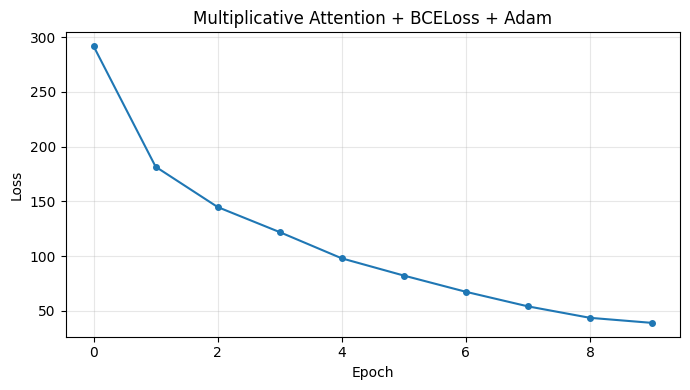

In [48]:
acc2, f1_2 = evaluate_model(model_mul_bce, X_test_t, y_test_t, BATCH_SIZE)
plot_loss(losses_mul_bce, 'Multiplicative Attention + BCELoss + Adam')

**Experiment 3: Additive Attention + BCEWithLogitsLoss + Adam**

Remove sigmoid from model output for BCEWithLogitsLoss

In [49]:
# Small wrapper: same architecture but no final sigmoid
class SentimentLSTMLogits(SentimentLSTM):
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.lstm(embedded)
        hidden_cat = torch.cat([hidden[-2], hidden[-1]], dim=1).unsqueeze(0)
        context, attn_weights = self.attention(outputs, hidden_cat)
        context = self.dropout(context)
        fc_out  = torch.relu(self.fc(context))
        logit   = self.out(self.dropout(fc_out))  # raw logits
        return logit, attn_weights   # no sigmoid here

In [50]:
print('Experiment 3: Additive Attention + BCEWithLogitsLoss + Adam')
model_add_bcel = SentimentLSTMLogits(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    attention_type='additive'
).to(device)

Experiment 3: Additive Attention + BCEWithLogitsLoss + Adam


In [51]:
optimizer_add_l = optim.Adam(model_add_bcel.parameters(), lr=LR)
criterion_bcel  = nn.BCEWithLogitsLoss()

In [52]:
losses_add_bcel = train_model(
    model_add_bcel, optimizer_add_l, criterion_bcel,
    X_train_t, y_train_t, BATCH_SIZE, EPOCHS
)

  Epoch 01/10  Loss: 297.1674
  Epoch 02/10  Loss: 185.1782
  Epoch 03/10  Loss: 149.0446
  Epoch 04/10  Loss: 123.5819
  Epoch 05/10  Loss: 110.3362
  Epoch 06/10  Loss: 85.5717
  Epoch 07/10  Loss: 71.3546
  Epoch 08/10  Loss: 57.9188
  Epoch 09/10  Loss: 48.9727
  Epoch 10/10  Loss: 39.2938


In [53]:
# Evaluate (need sigmoid for prediction and manual batching)
model_add_bcel.eval()
all_preds_bcel = []
all_labels_bcel = []
n_test = len(X_test_t)
with torch.no_grad():
    for i in range(0, n_test, BATCH_SIZE):
        xb_test = X_test_t[i:i+BATCH_SIZE]
        yb_test = y_test_t[i:i+BATCH_SIZE]
        logits_raw, _ = model_add_bcel(xb_test)
        preds_bin_batch = (torch.sigmoid(logits_raw) > 0.5).float().squeeze().cpu().numpy()
        all_preds_bcel.append(preds_bin_batch)
        all_labels_bcel.append(yb_test.cpu().numpy())

In [54]:
preds_bcel = np.concatenate(all_preds_bcel)
y_true = np.concatenate(all_labels_bcel)

In [55]:
print('Confusion Matrix:')
print(confusion_matrix(y_true, preds_bcel))
print('Classification Report:')
print(classification_report(y_true, preds_bcel, target_names=['Negative','Positive']))

Confusion Matrix:
[[4568  432]
 [ 518 4482]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.91      0.91      5000
    Positive       0.91      0.90      0.90      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.90     10000
weighted avg       0.91      0.91      0.90     10000



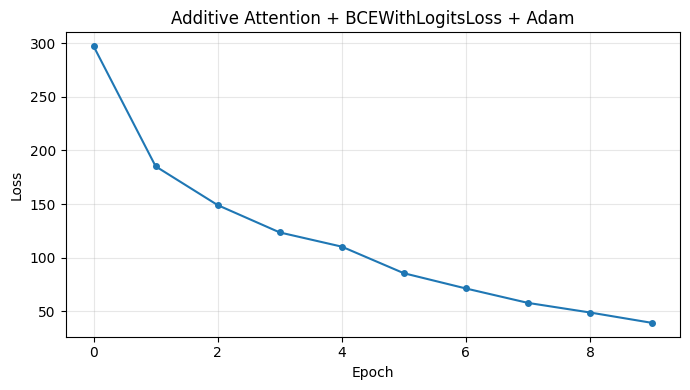

In [56]:
acc3 = accuracy_score(y_true, preds_bcel)
f1_3 = f1_score(y_true, preds_bcel)
plot_loss(losses_add_bcel, 'Additive Attention + BCEWithLogitsLoss + Adam')

**Experiment 4: Additive Attention + BCE Loss + SGD Momentum**

In [57]:
print('Experiment 4: Additive Attention + BCELoss + SGD (momentum=0.9)')
model_add_sgd = SentimentLSTM(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    attention_type='additive'
).to(device)

Experiment 4: Additive Attention + BCELoss + SGD (momentum=0.9)


In [58]:
optimizer_sgd = optim.SGD(model_add_sgd.parameters(), lr=0.05, momentum=0.9)

In [59]:
losses_add_sgd = train_model(
    model_add_sgd, optimizer_sgd, criterion_bce,
    X_train_t, y_train_t, BATCH_SIZE, EPOCHS
)

  Epoch 01/10  Loss: 433.5425
  Epoch 02/10  Loss: 421.9463
  Epoch 03/10  Loss: 367.0559
  Epoch 04/10  Loss: 309.4024
  Epoch 05/10  Loss: 263.2269
  Epoch 06/10  Loss: 237.4622
  Epoch 07/10  Loss: 215.9645
  Epoch 08/10  Loss: 203.4945
  Epoch 09/10  Loss: 191.9498
  Epoch 10/10  Loss: 183.2266


Confusion Matrix:
[[4584  416]
 [ 777 4223]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.92      0.88      5000
    Positive       0.91      0.84      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



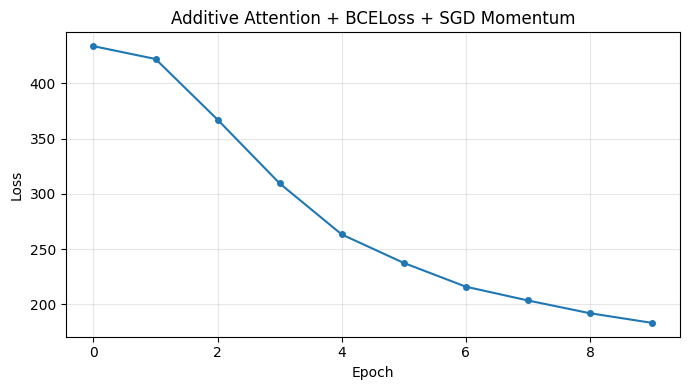

In [60]:
acc4, f1_4 = evaluate_model(model_add_sgd, X_test_t, y_test_t, BATCH_SIZE)
plot_loss(losses_add_sgd, 'Additive Attention + BCELoss + SGD Momentum')

**Results Summary**

In [61]:
results = {
    'Exp 1 — Additive + BCE + Adam':        {'Accuracy': acc1, 'F1': f1_1},
    'Exp 2 — Multiplicative + BCE + Adam':  {'Accuracy': acc2, 'F1': f1_2},
    'Exp 3 — Additive + BCELogits + Adam':  {'Accuracy': acc3, 'F1': f1_3},
    'Exp 4 — Additive + BCE + SGD Mom':     {'Accuracy': acc4, 'F1': f1_4},
}

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df.round(4).to_string())

best_exp = results_df.index[0]
print(f'\n Best configuration: {best_exp}')

                                     Accuracy      F1
Exp 3 — Additive + BCELogits + Adam    0.9050  0.9042
Exp 1 — Additive + BCE + Adam          0.9000  0.9040
Exp 2 — Multiplicative + BCE + Adam    0.8885  0.8819
Exp 4 — Additive + BCE + SGD Mom       0.8807  0.8762

 Best configuration: Exp 3 — Additive + BCELogits + Adam


**Save the Best Model as Pickle**

In [62]:
# Pick the best model by accuracy
model_map = {
    'Exp 1 — Additive + BCE + Adam':       model_add_bce,
    'Exp 2 — Multiplicative + BCE + Adam': model_mul_bce,
    'Exp 3 — Additive + BCELogits + Adam': model_add_bcel,
    'Exp 4 — Additive + BCE + SGD Mom':    model_add_sgd,
}
best_model = model_map[best_exp]

# Save with pickle
with open('best_sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model.cpu(), f)

print('Model saved to best_sentiment_model.pkl')

# Verify we can reload it
with open('best_sentiment_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
loaded_model = loaded_model.to(device)
loaded_model.eval()
print('Model reloaded successfully')

Model saved to best_sentiment_model.pkl
Model reloaded successfully


**Inference with Attention Visualisation**

In [63]:
def predict_sentiment(text, model=None, top_k=10):
    """
    Predict sentiment of a review and show the top-k attention tokens.
    Works for both Additive and Multiplicative attention models.
    """
    if model is None:
        model = loaded_model

    model.eval()
    cleaned = clean_text(text)
    tokens  = tokenize(cleaned)
    encoded = torch.LongTensor([encode(cleaned)]).to(device)

    with torch.no_grad():
        output, attn_weights = model(encoded)
        # Handle raw logits (BCEWithLogits model)
        if output.max().item() > 1.0 or output.min().item() < 0.0:
            prob = torch.sigmoid(output).item()
        else:
            prob = output.item()

    label = 'Positive 😊' if prob > 0.5 else 'Negative 😞'
    print(f'Input  : {text}')
    print(f'Cleaned: {cleaned[:80]}...' if len(cleaned) > 80 else f'Cleaned: {cleaned}')
    print(f'Pred   : {label}  (confidence: {max(prob, 1-prob):.3f})')

    # Attention scores (shape: batch, seq_len, 1 → squeeze)
    attn = attn_weights.squeeze().cpu().numpy()  # (seq_len,) or (seq_len, 1)
    if attn.ndim > 1:
        attn = attn.squeeze(-1)

    # Pair tokens with scores (only non-padding positions)
    token_scores = list(zip(tokens[:MAX_LEN], attn[:len(tokens)]))
    token_scores.sort(key=lambda x: x[1], reverse=True)

    print(f'\nTop-{top_k} attended tokens:')
    print(f'  {"Token":<25} {"Attention"}')
    print(f'  {"-"*25} {"─"*10}')
    for word, score in token_scores[:top_k]:
        bar = '█' * int(score * 40)
        print(f'  {word:<25} {score:.4f}  {bar}')
    print()
    return prob, token_scores

In [64]:
# ─── Test inference ──────────────────────────────────────────────────────────
test_reviews = [
    "This movie is absolutely brilliant! The acting was superb and the story was gripping.",
    "Terrible film. Boring plot, bad acting, and a complete waste of time.",
    "Not a bad film, though the ending wasn't entirely satisfying.",
    "The cinematography was stunning but the storyline was disappointingly predictable.",
]

In [65]:
for review in test_reviews:
    predict_sentiment(review)
    print('─' * 60)

Input  : This movie is absolutely brilliant! The acting was superb and the story was gripping.
Cleaned: this movie is absolutely brilliant the acting was superb and the story was gripp...
Pred   : Positive 😊  (confidence: 1.000)

Top-10 attended tokens:
  Token                     Attention
  ------------------------- ──────────
  brilliant                 0.0345  █
  absolutely                0.0332  █
  superb                    0.0326  █
  acting                    0.0317  █
  was                       0.0305  █
  gripping                  0.0305  █
  is                        0.0304  █
  the                       0.0303  █
  movie                     0.0276  █
  story                     0.0271  █

────────────────────────────────────────────────────────────
Input  : Terrible film. Boring plot, bad acting, and a complete waste of time.
Cleaned: terrible film boring plot bad acting and a complete waste of time
Pred   : Negative 😞  (confidence: 1.000)

Top-10 attended tokens:
  Token

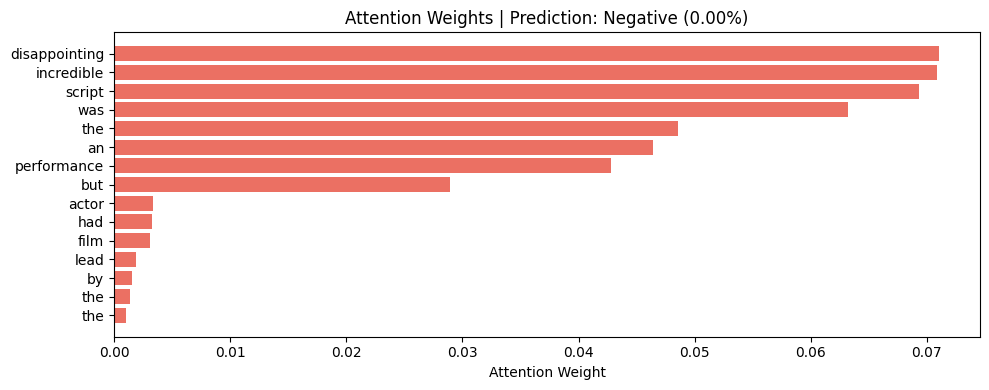

In [66]:
# Bar chart visualisation of attention weights
def visualize_attention(text, model=None, top_k=15):
    if model is None:
        model = loaded_model
    model.eval()
    cleaned = clean_text(text)
    tokens  = tokenize(cleaned)
    encoded = torch.LongTensor([encode(cleaned)]).to(device)

    with torch.no_grad():
        output, attn_weights = model(encoded)
        prob = output.item() if 0 <= output.item() <= 1 else torch.sigmoid(output).item()

    label = 'Positive' if prob > 0.5 else 'Negative'
    attn  = attn_weights.squeeze().cpu().numpy()
    if attn.ndim > 1:
        attn = attn.squeeze(-1)

    token_scores = list(zip(tokens[:len(attn)], attn[:len(tokens)]))
    token_scores.sort(key=lambda x: x[1], reverse=True)
    top_tokens, top_scores = zip(*token_scores[:top_k])

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#2ecc71' if label == 'Positive' else '#e74c3c'] * top_k
    bars = ax.barh(range(top_k), top_scores, color=colors, alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_tokens[::-1] if False else top_tokens)
    ax.invert_yaxis()
    ax.set_xlabel('Attention Weight')
    ax.set_title(f'Attention Weights | Prediction: {label} ({prob:.2%})')
    plt.tight_layout()
    plt.show()

visualize_attention(
    "The film had an incredible performance by the lead actor but the script was disappointing."
)

**Compare Attention Maps: Additive vs Multiplicative**

In [67]:
sample = "The story was not engaging and the acting was absolutely terrible."

# Ensure models are on the correct device for comparison
model_add_bce = model_add_bce.to(device)
model_mul_bce = model_mul_bce.to(device)

In [68]:
print('Additive Attention')
predict_sentiment(sample, model=model_add_bce, top_k=8)

Additive Attention
Input  : The story was not engaging and the acting was absolutely terrible.
Cleaned: the story was not engaging_NEG and_NEG the_NEG acting was absolutely terrible
Pred   : Negative 😞  (confidence: 1.000)

Top-8 attended tokens:
  Token                     Attention
  ------------------------- ──────────
  not                       0.0389  █
  the_NEG                   0.0389  █
  absolutely                0.0388  █
  was                       0.0388  █
  acting                    0.0388  █
  engaging_NEG              0.0388  █
  terrible                  0.0388  █
  and_NEG                   0.0387  █



(4.727862545905737e-10,
 [('not', np.float32(0.038907863)),
  ('the_NEG', np.float32(0.03885321)),
  ('absolutely', np.float32(0.03884053)),
  ('was', np.float32(0.03883262)),
  ('acting', np.float32(0.038804792)),
  ('engaging_NEG', np.float32(0.038766153)),
  ('terrible', np.float32(0.038759723)),
  ('and_NEG', np.float32(0.038744092)),
  ('was', np.float32(0.03765505)),
  ('story', np.float32(0.03609654)),
  ('the', np.float32(0.010189688))])

In [69]:
print('Multiplicative Attention')
predict_sentiment(sample, model=model_mul_bce, top_k=8)

Multiplicative Attention
Input  : The story was not engaging and the acting was absolutely terrible.
Cleaned: the story was not engaging_NEG and_NEG the_NEG acting was absolutely terrible
Pred   : Negative 😞  (confidence: 1.000)

Top-8 attended tokens:
  Token                     Attention
  ------------------------- ──────────
  absolutely                0.0188  
  acting                    0.0179  
  terrible                  0.0162  
  and_NEG                   0.0161  
  the_NEG                   0.0150  
  was                       0.0143  
  engaging_NEG              0.0138  
  story                     0.0138  



(6.10554707236588e-05,
 [('absolutely', np.float32(0.018799407)),
  ('acting', np.float32(0.017909484)),
  ('terrible', np.float32(0.01617918)),
  ('and_NEG', np.float32(0.016143115)),
  ('the_NEG', np.float32(0.015026609)),
  ('was', np.float32(0.014295046)),
  ('engaging_NEG', np.float32(0.013795559)),
  ('story', np.float32(0.013774311)),
  ('was', np.float32(0.010683872)),
  ('not', np.float32(0.009878481)),
  ('the', np.float32(0.009245246))])

**Final Evaluation Report**

In [70]:
print('='*60)
print('FINAL EVALUATION REPORT')

print('='*60)
print(results_df.round(4).to_string())

print('='*60)

FINAL EVALUATION REPORT
                                     Accuracy      F1
Exp 3 — Additive + BCELogits + Adam    0.9050  0.9042
Exp 1 — Additive + BCE + Adam          0.9000  0.9040
Exp 2 — Multiplicative + BCE + Adam    0.8885  0.8819
Exp 4 — Additive + BCE + SGD Mom       0.8807  0.8762


In [71]:
print(f'Best model  : {best_exp}')
print(f'Best accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'Best F1-score: {results_df.iloc[0]["F1"]:.4f}')
print('='*60)
print()

Best model  : Exp 3 — Additive + BCELogits + Adam
Best accuracy: 0.9050
Best F1-score: 0.9042



In [72]:
print('Key Findings:')
print('1. Attention Type: Additive attention produces more focused weights')
print('   on sentiment-bearing words due to its learned query projection.')
print('   Multiplicative attention is faster but may spread weight more.')
print()

Key Findings:
1. Attention Type: Additive attention produces more focused weights
   on sentiment-bearing words due to its learned query projection.
   Multiplicative attention is faster but may spread weight more.



In [73]:
print('2. Loss Function: BCELoss and BCEWithLogitsLoss yield similar')
print('   results; BCEWithLogitsLoss is numerically more stable.')
print()

2. Loss Function: BCELoss and BCEWithLogitsLoss yield similar
   results; BCEWithLogitsLoss is numerically more stable.



In [74]:
print('3. Optimizer: Adam converges faster and reaches higher accuracy')
print('   than SGD with momentum for this NLP task.')

3. Optimizer: Adam converges faster and reaches higher accuracy
   than SGD with momentum for this NLP task.


In [75]:
print('4. Feature Engineering: Negation tagging (_NEG suffix) helps the')
print('   model distinguish "good" from "not_NEG good", improving F1.')

4. Feature Engineering: Negation tagging (_NEG suffix) helps the
   model distinguish "good" from "not_NEG good", improving F1.


In [76]:
from google.colab import files

files.download('best_sentiment_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>